# Options

This notebook provides a structured introduction to options and demonstrates how options strategies can be incorporated into quantitative portfolio construction, risk management, and return enhancement frameworks.

---

We will be delving into the basics of Options, before moving on to talk about some common options strategies

Import the necessary libraries

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Put Payoff

We will define a function that calculates the payoff from buying a put option. The function takes $s_t$ which is a range of possible values of the stock price at expiration, the strike price of the put option and premium of the put option as input. It returns the put option payoff.

Recall:
- When the stock price $s_t$ is less than the strike price at expiration, the Put option is in the money and the payoff is the difference (i.e $Strike Price - s_t$)
- When the stock price $s_t$ is greater than the strike price at expiration, the Put option expires worthless


In [ ]:
def put_payoff(sT, strike_price, premium):
  return np.where(sT < strike_price, strike_price - sT, 0) - premium

#### Call Payoff

We will define a function that calculates the payoff from buying a call option. The function takes $s_t$ which is a range of possible values of the stock price at expiration, the strike price of the call option and premium of the call option as input. It returns the call option payoff.

Recall:
- When the stock price $s_t$ is greater than the strike price at expiration, the call option is in the money and the payoff is the difference (i.e $s_t - Strike Price$)
- When the stock price $s_t$ is less than the strike price at expiration, the call option expires worthless

In [35]:
def call_payoff(sT, strike_price, premium):
  return np.where(sT > strike_price, sT - strike_price, 0) - premium

We will define a payoff plot for the ease of plotting simple option payoff charts

In [36]:
def pay_off_plot(sT, payoffs, label_info, line_colour='g'):
  fig, ax = plt.subplots(figsize=(15, 5))
  ax.spines['bottom'].set_position('zero')
  ax.plot(sT,payoffs,label=label_info,color=line_colour)
  plt.xlabel('XYZ Stock Price')
  plt.ylabel('Payoff')
  plt.title('Option Payoff at Expiry')
  plt.legend()
  plt.show()

#### Put Payoff Example

Let us visualise the Put Payoff with the following information
- The $Strike Price$ of our **long** put is $880
- The $Strike Price$ of our **short** put is $860
- The $Spot Price$ is $900
- Premium paid for the **long** put is 15
- Premium paid for the **short** put is 10

In [37]:
spot_price = 900 

# Long put
strike_price_long_put = 880 
premium_long_put = 15

# Short put
strike_price_short_put = 860 
premium_short_put = 10

# Stock price range at expiration of the put
sT = np.arange(0.9*spot_price,1.05*spot_price,1) 

**Long 880 Strike Put Payoff**

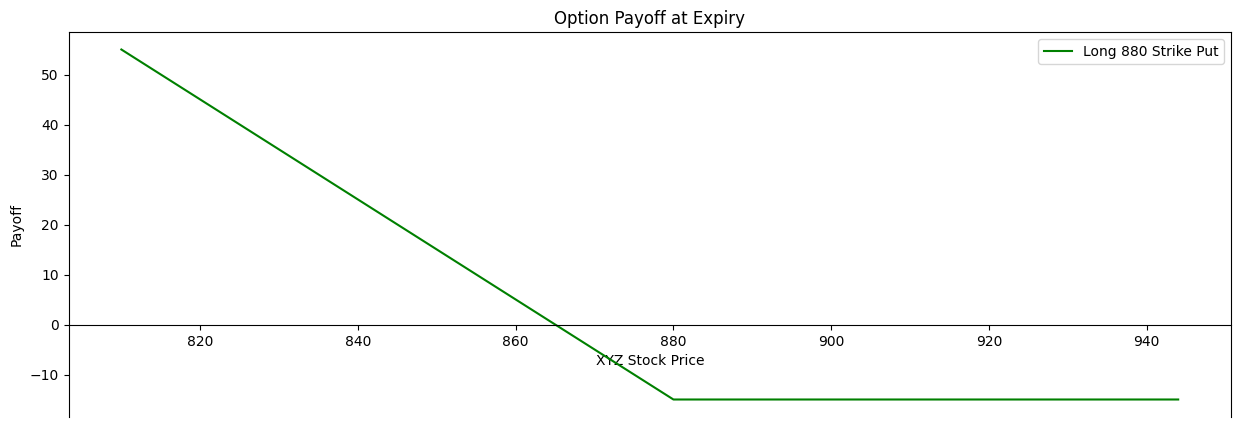

In [38]:
payoff_long_put = put_payoff(sT, strike_price_long_put, premium_long_put)
pay_off_plot(sT, payoff_long_put, 'Long 880 Strike Put')

**Short 860 Strike Put Payoff**

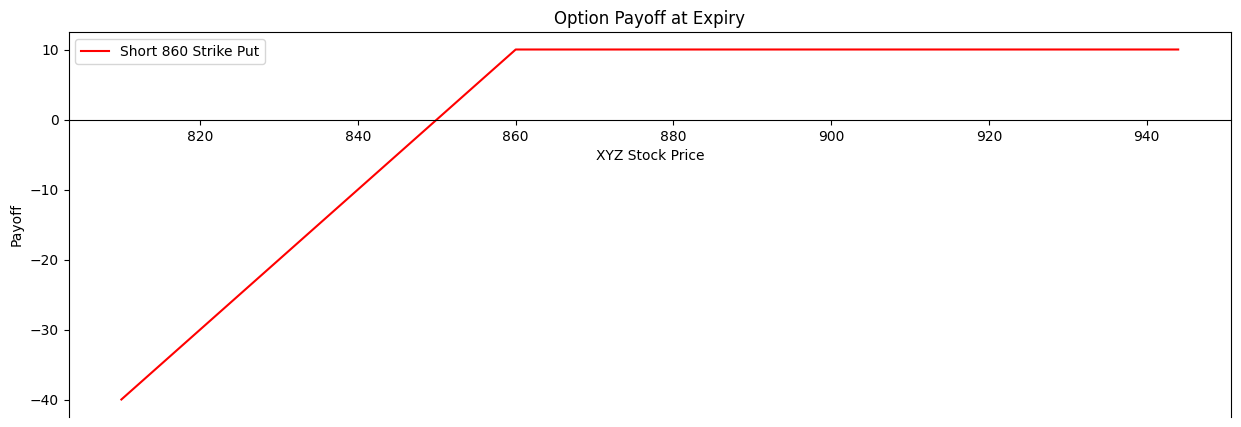

In [39]:
payoff_short_put = -put_payoff(sT, strike_price_short_put, premium_short_put)
pay_off_plot(sT, payoff_short_put, 'Short 860 Strike Put', 'r')

#### Call Payoff Example

Let us visualise the Call Payoff with the following information
- The $Strike Price$ of our **long** call is $920
- The $Strike Price$ of our **short** call is $940
- The $Spot Price$ is $900
- Premium paid for the **long** call is 15
- Premium paid for the **short** call is 10

In [41]:
spot_price = 900

# Long call
strike_price_long_call = 920
premium_long_call = 15

# Short call
strike_price_short_call = 940
premium_short_call = 10

# Stock price range at expiration of the call
sT = np.arange(0.95*spot_price, 1.1*spot_price, 1)

**Long 920 Strike Call Payoff**

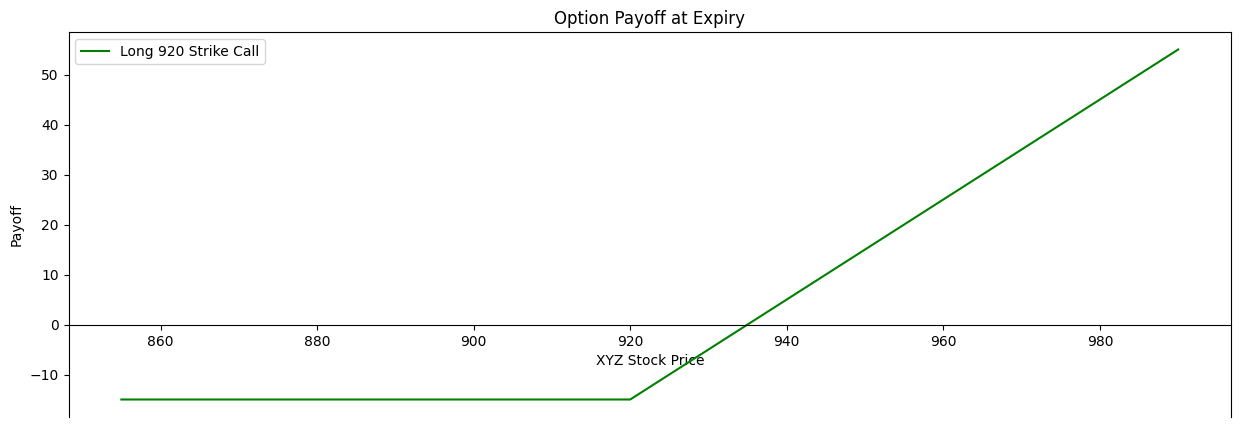

In [42]:
payoff_long_call = call_payoff(sT, strike_price_long_call, premium_long_call)
# Plot
pay_off_plot(sT, payoff_long_call, 'Long 920 Strike Call')

**Short 940 Strike Call Payoff**

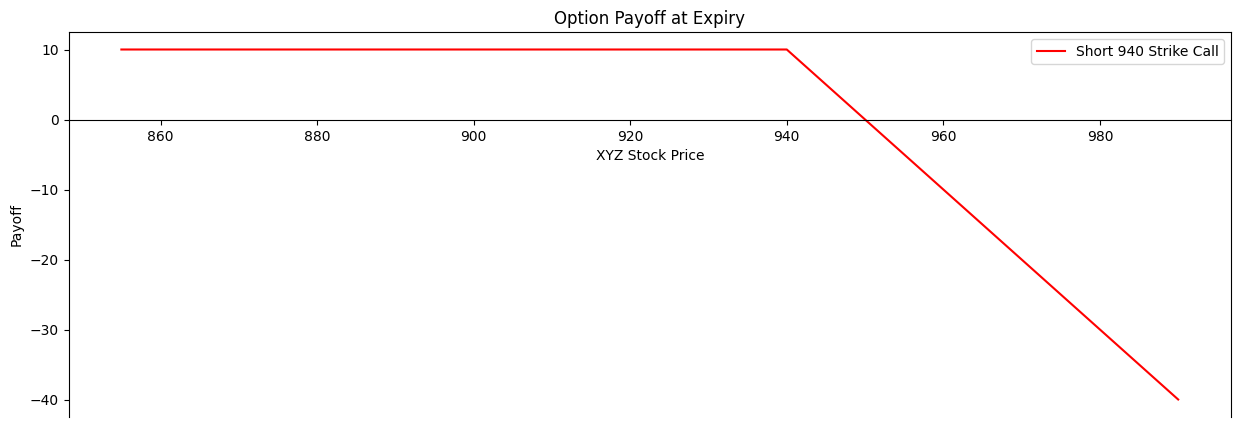

In [43]:
payoff_short_call = -call_payoff(sT, strike_price_short_call, premium_short_call)
# Plot
pay_off_plot(sT, payoff_short_call, 'Short 940 Strike Call', 'r')

#### Option Strategy 1: Bear Put Spread

A Bear Put Spread is a bearish options strategy that involves buying a put option at a higher strike price and simultaneously selling another put option at a lower strike price. This structure reduces the net premium paid compared to a single long put while limiting both the maximum profit and maximum loss. The strategy benefits from a moderate decline in the underlying asset’s price before expiration. Looking at our long and short puts, our bear put spread payoff formula is simply:

$$
payoff_{bear put spread} = payoff_{long put} + payoff_{short put}
$$

Max Profit: 15.0
Max Loss: -5.0


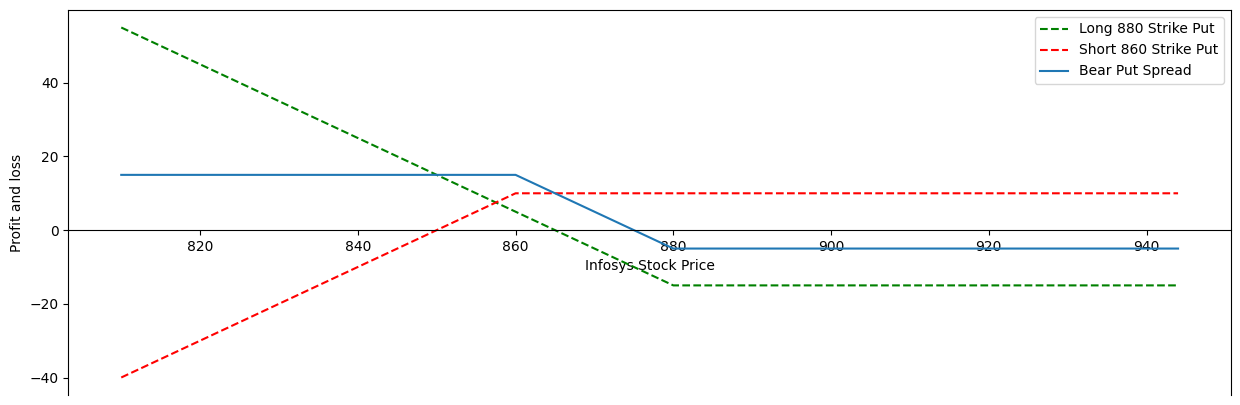

In [40]:
payoff_bear_put_spread = payoff_long_put + payoff_short_put

print("Max Profit:", max(payoff_bear_put_spread))
print("Max Loss:", min(payoff_bear_put_spread))

fig, ax = plt.subplots(figsize=(15, 5))
ax.spines['bottom'].set_position('zero')
ax.plot(sT,payoff_long_put,'--',label='Long 880 Strike Put',color='g')
ax.plot(sT,payoff_short_put,'--',label='Short 860 Strike Put',color='r')
ax.plot(sT,payoff_bear_put_spread,label='Bear Put Spread')
plt.xlabel('Infosys Stock Price')
plt.ylabel('Profit and loss')
plt.legend()
plt.show()

The max profit is capped at $15 and the max loss is limited to $5. Therefore, this strategy is suitable when your outlook is moderately bearish on the stock. 

#### Option Strategy 2: Bull Call Spread

A bull call spread strategy is built by going long on call option and simultaneously selling a higher strike call option. This strategy aims to benefit from small positive movements in the stock. 

Looking at our long and short calls, our bull call spread payoff formula is simply:

$$
payoff_{bull call spread} = payoff_{long call} + payoff_{short call}
$$


Max Profit: 15.0
Max Loss: -5.0


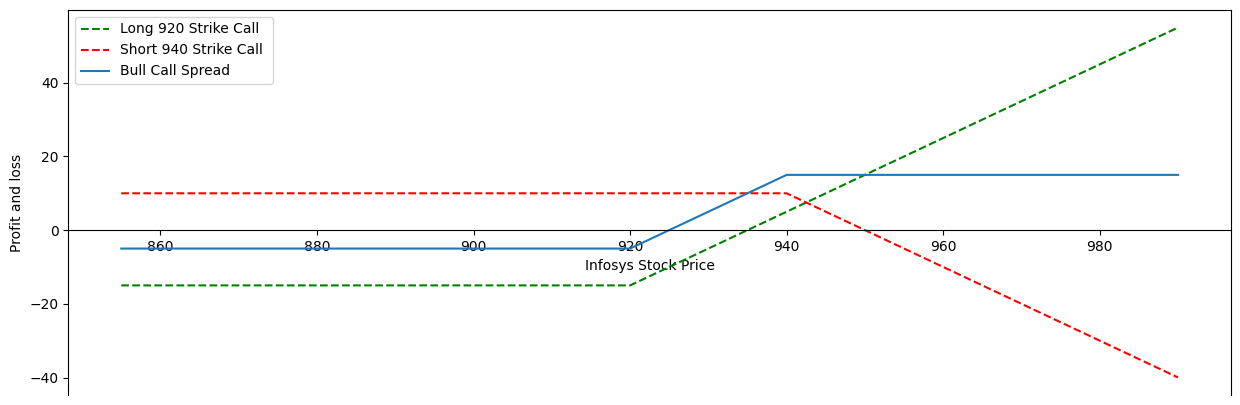

In [44]:
payoff_bull_call_spread = payoff_long_call + payoff_short_call

print("Max Profit:", max(payoff_bull_call_spread))
print("Max Loss:", min(payoff_bull_call_spread))

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.spines['bottom'].set_position('zero')
ax.plot(sT, payoff_long_call, '--', label='Long 920 Strike Call', color='g')
ax.plot(sT, payoff_short_call, '--', label='Short 940 Strike Call ', color='r')
ax.plot(sT, payoff_bull_call_spread, label='Bull Call Spread')
plt.xlabel('Infosys Stock Price')
plt.ylabel('Profit and loss')
plt.legend()
plt.show()

The max profit is capped at $15 and the max loss is limited to $5. Therefore, this strategy is suitable when your outlook is moderately bullish on the stock. 

#### Options Strategy 3: Covered Call

A Covered Call is an income-generating strategy that involves holding a long position in an underlying asset while simultaneously selling a call option on that same asset. The premium received from selling the call provides immediate income and offers partial downside protection. However, the upside potential is capped at the call’s strike price if the asset appreciates significantly.

Using the same information as the above, we can visualise covered call as follow

Max Profit: 50.0


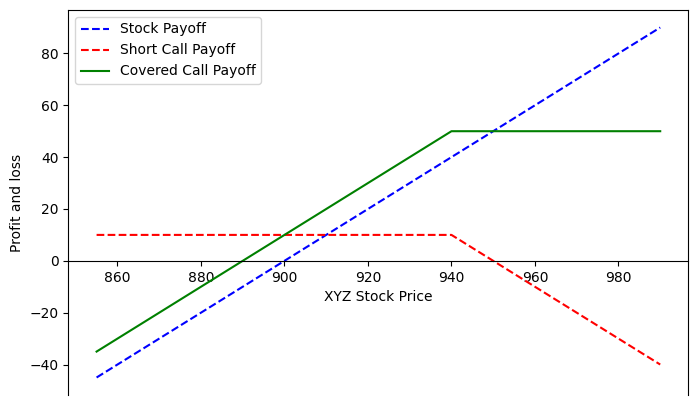

In [49]:
spot = spot_price

# Short call
short_call_premium_strike = strike_price_short_call
short_call_premium = premium_short_call

# Buy and hold the stock
xyz_payoff = sT - spot

# Sell the call option
xyz_payoff_short_call = -call_payoff(sT, short_call_premium_strike, short_call_premium)

# Covered call payoff
xyz_covered_call_payoff = xyz_payoff + xyz_payoff_short_call

print("Max Profit:", max(xyz_covered_call_payoff))


fig, ax = plt.subplots(figsize=(8,5))
ax.spines['bottom'].set_position('zero')
ax.plot(sT,xyz_payoff,'--',label='Stock Payoff',color='b')
ax.plot(sT,xyz_payoff_short_call,'--',label='Short Call Payoff',color='r')
ax.plot(sT,xyz_covered_call_payoff,label='Covered Call Payoff',color='g')
plt.xlabel('XYZ Stock Price')
plt.ylabel('Profit and loss')
plt.legend()
plt.show()

The max profit is capped at $50 if XYZ stock moves to any price above $940. Anything below $940, the loss stemming from this strategy is proportional to price fall.

#### Option Strategy 4: Protective Put

A Protective Put is a risk-management strategy that involves holding a long position in an underlying asset while purchasing a put option on the same asset. The put acts as insurance, providing downside protection by setting a minimum exit price. While the strategy preserves unlimited upside potential, the cost of the put reduces overall returns.

Max Loss: -35.0


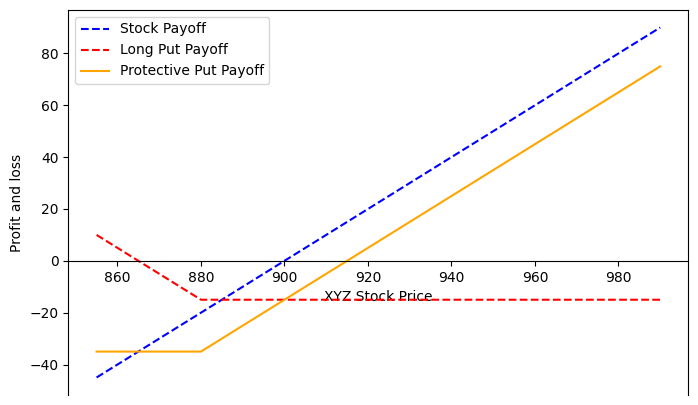

In [50]:
spot = spot_price

# Long put
long_put_strike = strike_price_long_put
long_put_premium = premium_long_put

# Buy and hold the stock
xyz_payoff = sT - spot

# Put option payoff
xyz_payoff_long_put = put_payoff(sT, long_put_strike, long_put_premium)

# Protective put payoff
xyz_protective_put_payoff = xyz_payoff + xyz_payoff_long_put

print("Max Loss:", min(xyz_protective_put_payoff))

fig, ax = plt.subplots(figsize=(8,5))
ax.spines['bottom'].set_position('zero')
ax.plot(sT,xyz_payoff,'--',label='Stock Payoff',color='b')
ax.plot(sT,xyz_payoff_long_put,'--',label='Long Put Payoff',color='r')
ax.plot(sT,xyz_protective_put_payoff,label='Protective Put Payoff',color='orange')
plt.xlabel('XYZ Stock Price')
plt.ylabel('Profit and loss')
plt.legend()
plt.show()

The max loss is capped at -$35 if the stock price falls below $880, whereas the max gains is unlimited. The gains is proportional to the stock price movememnt $880.